In [9]:
import os
import time
import random
import warnings

import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq
from lxml import etree # type: ignore <- pylance milně hlásí chybu
from pathlib import Path
import time
import sys
import polars as pl
import polars.selectors as cs
import json
import pickle
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mtick
import matplotlib.patheffects as path_effects
from ydata_profiling import ProfileReport
import geopandas as gpd


current_dir = Path(__file__).resolve().parent if "__file__" in locals() else Path.cwd()
sys.path.append(str(current_dir.parent))
from utils import *
from schemas import *
from clean import *
from visualisation_utils import *

pl.Config.set_tbl_cols(-1)
os.chdir(r'E:\CVUT_BAP')
SEED=42

# Načtení datasetu se stanicemi

In [10]:
df = pl.read_parquet(r'kod\data\extracted\stanice_stk_a_sme\parquet\Stanice STK a SME.parquet', schema=stanice_schema)
describe(df)

Stanice_Cislo,Stanice_Adresa_Kraj,Stanice_Adresa_Okres,Stanice_Adresa_Orp,Stanice_Adresa_Obec,Stanice_Adresa_Ulice,Stanice_Adresa_Psc,Stanice_Kontakt_Telefon,Stanice_Kontakt_Email,Provozovatel_Ico,Provozovatel_Nazev,Provozovatel_Adresa_Obec,Provozovatel_Adresa_Ulice,Provozovatel_Adresa_Psc,Provozovatel_Kontakt_Telefon,Provozovatel_Kontakt_Email,Stk_Pritomno,Stk_Osvedceni_Kategorie,Adr_Pritomno,Adr_Osvedceni_Kategorie,SmeZkusebni_Pritomno,SmeZkusebni_Osvedceni_Kategorie,Sme_Pritomno,Sme_Osvedceni_Kategorie,Sme_Osvedceni_EmisniSystem,Sme_Osvedceni_Palivo
str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,list[str],str,list[str],str,list[str],str,list[str],list[str],list[str]
"""110301""","""Hlavní město Praha""","""Hlavní město Praha""","""Hlavní město Praha""","""Praha""","""Koněvova 411/143""","""13000""","""704372631""","""emitech@email.cz""","""17389631""","""Emitech s.r.o.""","""Praha""","""Choceradská 3046""","""14100""","""704 372 000""","""emitech@email.cz""","""False""",null,"""False""",null,"""False""",null,"""True""","[""M1"", ""M2"", … ""N2""]","[""NERIZENY"", ""RIZENY""]","[""BA"", ""NM""]"


(1411, 26)


,Stanice_Cislo,Stanice_Adresa_Kraj,Stanice_Adresa_Okres,Stanice_Adresa_Orp,Stanice_Adresa_Obec,Stanice_Adresa_Ulice,Stanice_Adresa_Psc,Stanice_Kontakt_Telefon,Stanice_Kontakt_Email,Provozovatel_Ico,...,Stk_Pritomno,Stk_Osvedceni_Kategorie,Adr_Pritomno,Adr_Osvedceni_Kategorie,SmeZkusebni_Pritomno,SmeZkusebni_Osvedceni_Kategorie,Sme_Pritomno,Sme_Osvedceni_Kategorie,Sme_Osvedceni_EmisniSystem,Sme_Osvedceni_Palivo
0,110301,Hlavní město Praha,Hlavní město Praha,Hlavní město Praha,Praha,Koněvova 411/143,13000,704372631,emitech@email.cz,17389631,...,False,NaN,False,NaN,False,NaN,True,4.0,2.0,2.0
1,110302,Hlavní město Praha,Hlavní město Praha,Hlavní město Praha,Praha,Osiková 2688/2,13000,605339922,stk3130@seznam.cz,7100639,...,False,NaN,False,NaN,False,NaN,True,2.0,2.0,4.0
2,110401,Hlavní město Praha,Hlavní město Praha,Hlavní město Praha,Praha,Lipenská 616,14900,608238686,m.o.t.service@centrum.cz,71715177,...,False,NaN,False,NaN,False,NaN,True,2.0,2.0,4.0
3,110501,Hlavní město Praha,Hlavní město Praha,Hlavní město Praha,Praha,Bavorská 2666/16,15500,+420 271 077 890,ota.kolmann@daimlertruck.com,6418147,...,False,NaN,False,NaN,False,NaN,True,9.0,2.0,3.0
4,110502,Hlavní město Praha,Hlavní město Praha,Hlavní město Praha,Praha,Jeremiášova 947/16,15500,774264790,autosprint.stodulky@gmail.com,11716541,...,False,NaN,False,NaN,False,NaN,True,7.0,2.0,3.0
5,110503,Hlavní město Praha,Hlavní město Praha,Hlavní město Praha,Praha,Plzeňská 305/215e,15000,257216489,sen.k.trojan@seznam.cz,17145279,...,False,NaN,False,NaN,False,NaN,True,2.0,2.0,4.0
6,110601,Hlavní město Praha,Hlavní město Praha,Hlavní město Praha,Praha,Reinerova 811/5,16300,608910916,recepce@papousek.cz,48028321,...,False,NaN,False,NaN,False,NaN,True,2.0,2.0,2.0
7,110801,Hlavní město Praha,Hlavní město Praha,Hlavní město Praha,Praha,Bešťákova 567/3,18200,722003300,stk@stkpraha8.cz,24847224,...,False,NaN,False,NaN,False,NaN,True,7.0,2.0,4.0
8,110802,Hlavní město Praha,Hlavní město Praha,Hlavní město Praha,Praha,K Ládví 925,18000,604288244,autoholub@email.cz,62421247,...,False,NaN,False,NaN,False,NaN,True,7.0,2.0,4.0
9,110901,Hlavní město Praha,Hlavní město Praha,Hlavní město Praha,Praha,"Kostelecká ul., parc.č.756/48,756/49,756/50,15788",19000,777277177,stk31.31@seznam.cz,7100639,...,False,NaN,False,NaN,False,NaN,True,2.0,2.0,4.0


,column,majority_class,majority_cnt,non_null,dtype
0,Stanice_Cislo,3418,1 / 1 411,1 411 / 1 411,String
1,Stanice_Adresa_Kraj,Středočeský kraj,170 / 1 411,1 411 / 1 411,String
2,Stanice_Adresa_Okres,Hlavní město Praha,146 / 1 411,1 411 / 1 411,String
3,Stanice_Adresa_Orp,Hlavní město Praha,146 / 1 411,1 411 / 1 411,String
4,Stanice_Adresa_Obec,Praha,146 / 1 411,1 411 / 1 411,String
5,Stanice_Adresa_Ulice,Průmyslová 1208,4 / 1 411,1 411 / 1 411,String
6,Stanice_Adresa_Psc,77900,16 / 1 411,1 411 / 1 411,String
7,Stanice_Kontakt_Telefon,608555011,7 / 1 411,1 411 / 1 411,String
8,Stanice_Kontakt_Email,karelmanas@centrum.cz,6 / 1 411,1 411 / 1 411,String
9,Provozovatel_Ico,49240188,60 / 1 411,1 411 / 1 411,String


# Chybějící hodnoty

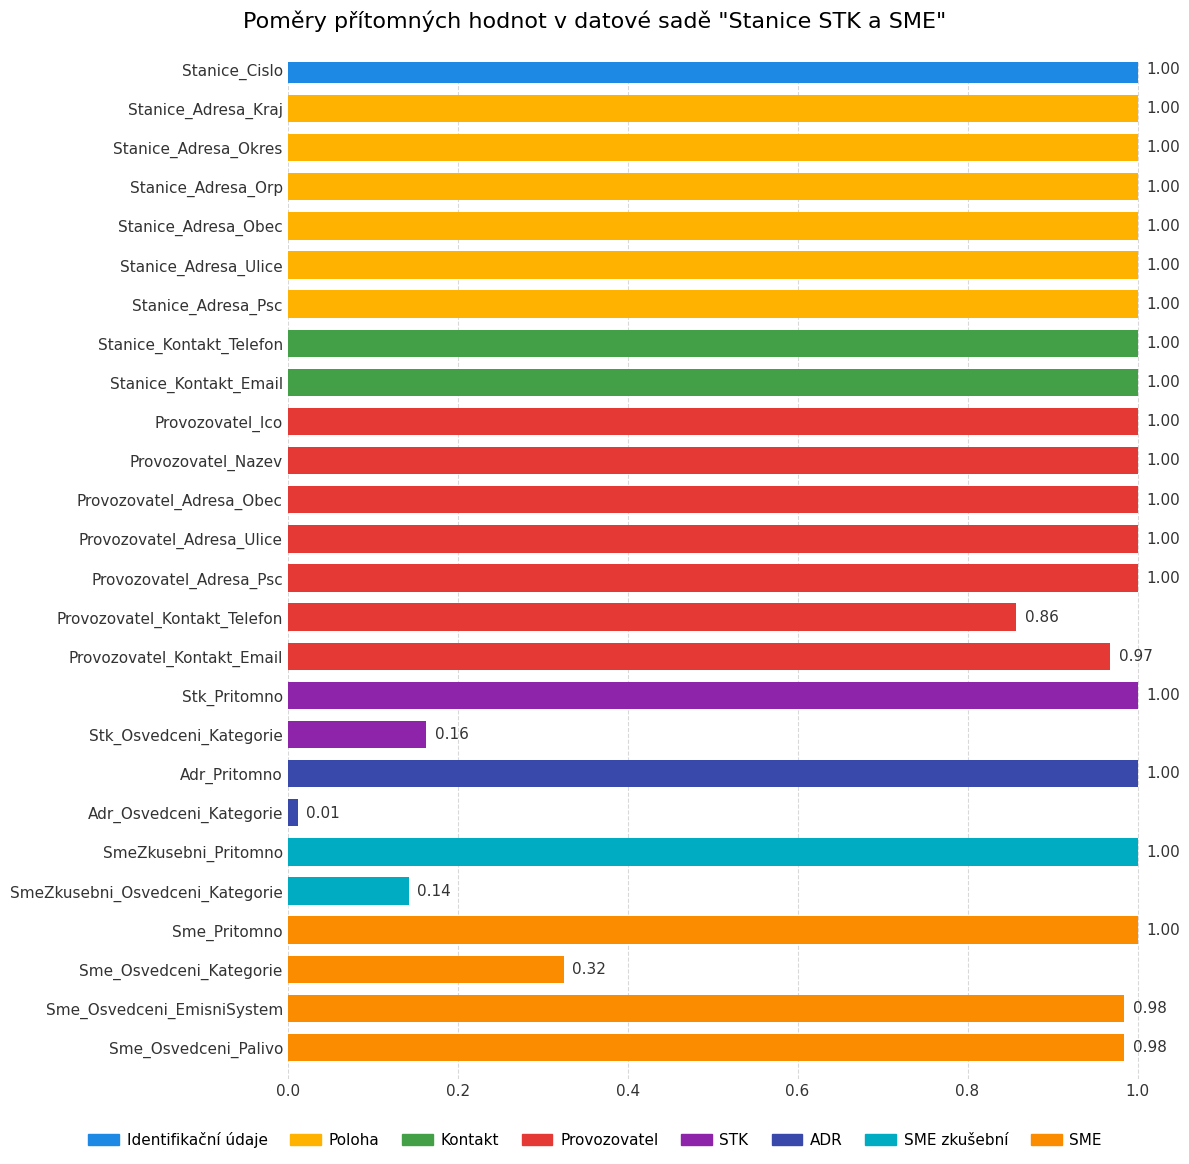

In [11]:
# Výpočet metrik
total_rows = len(df)
null_counts = df.null_count().row(0)
non_null_counts = [total_rows - count for count in null_counts]
ratios = [count / total_rows for count in non_null_counts]
columns = df.columns

horizontal_bar(columns[::-1], ratios[::-1], 'Poměry přítomných hodnot v datové sadě "Stanice STK a SME"' , "kod/explorace/stanice_pritomne_hodnoty.svg", False, 12, [1, 6, 2, 7, 2, 2, 2, 4], ['Identifikační údaje', 'Poloha', 'Kontakt', 'Provozovatel', 'STK', 'ADR', 'SME zkušební', 'SME'])

# Oprávnění

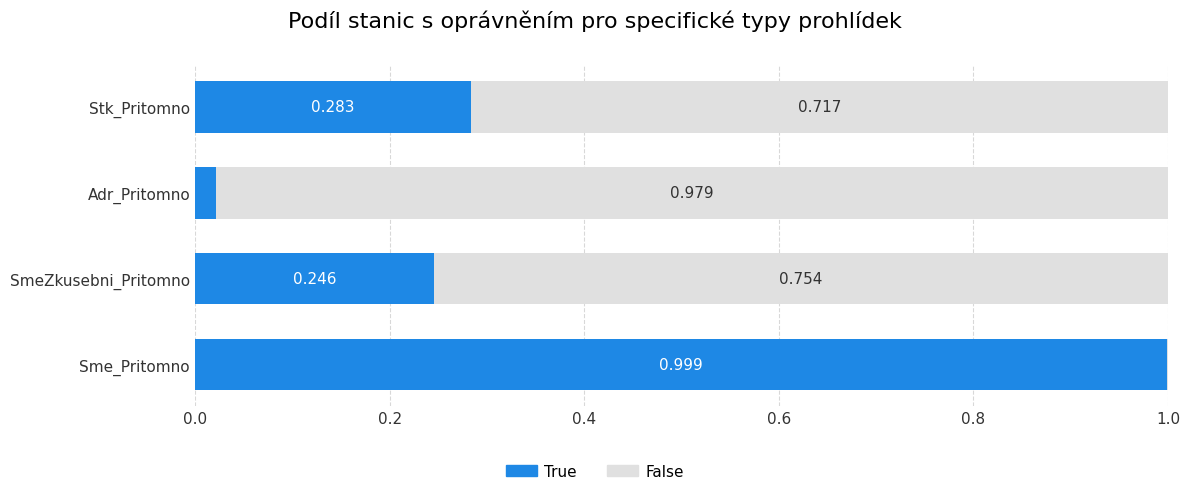

In [12]:
cols_to_plot = ["Stk_Pritomno", "Adr_Pritomno", "SmeZkusebni_Pritomno", "Sme_Pritomno",]

# 2. Definice parametrů pro zobrazení
graph_title = "Podíl stanic s oprávněním pro specifické typy prohlídek"
output_file = "kod/explorace/stanice_opravneni.svg"

# 3. Samotné volání funkce
plot_stacked_ratios(df=df, cols=cols_to_plot[::-1], title=graph_title, save_path=output_file)

# Počty stanic v krajích

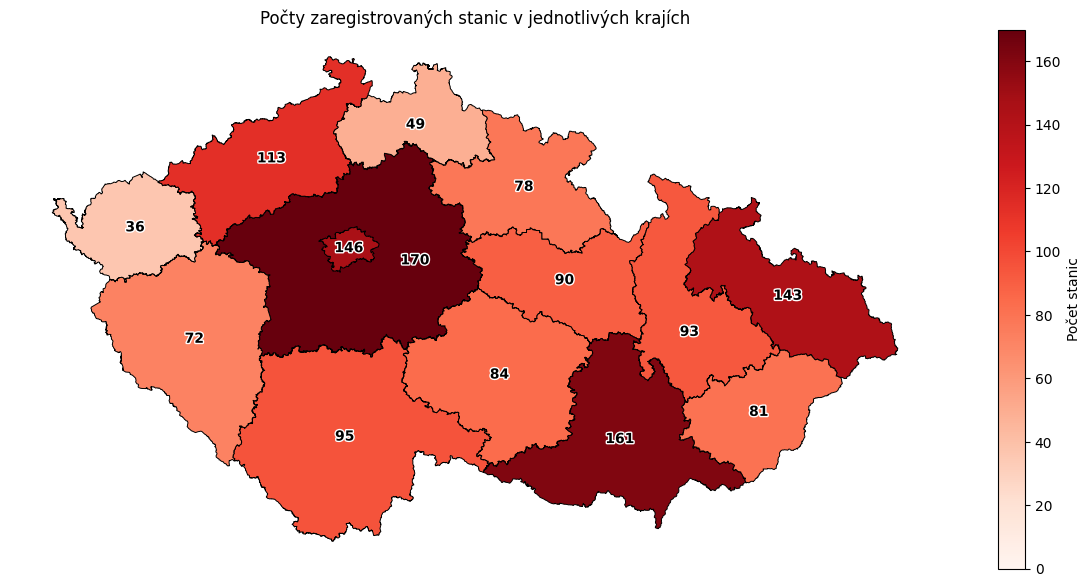

In [13]:
# Definice převodníku
kraje_mapping = {
    "Hlavní město Praha": "CZ0100000000",
    "Středočeský kraj": "CZ0200000000",
    "Jihočeský kraj": "CZ0310000000",
    "Plzeňský kraj": "CZ0320000000",
    "Karlovarský kraj": "CZ0410000000",
    "Ústecký kraj": "CZ0420000000",
    "Liberecký kraj": "CZ0510000000",
    "Královéhradecký kraj": "CZ0520000000",
    "Pardubický kraj": "CZ0530000000",
    "Vysočina": "CZ0630000000",
    "Jihomoravský kraj": "CZ0640000000",
    "Olomoucký kraj": "CZ0710000000",
    "Zlínský kraj": "CZ0720000000",
    "Moravskoslezský kraj": "CZ0800000000"
}

# Agregace v Polars
counts_pl = df.with_columns(pl.col("Stanice_Adresa_Kraj").replace(kraje_mapping).alias("kod_kraje")).group_by("kod_kraje").agg(pl.len().alias("pocet"))

plot_czech_regional_map(counts_pl=counts_pl, value_column="pocet", title='Počty zaregistrovaných stanic v jednotlivých krajích', legend_label="Počet stanic", output_path="kod/explorace/stanice_pocty_mapa.svg")

# Stanice pod stejným provozovatelem

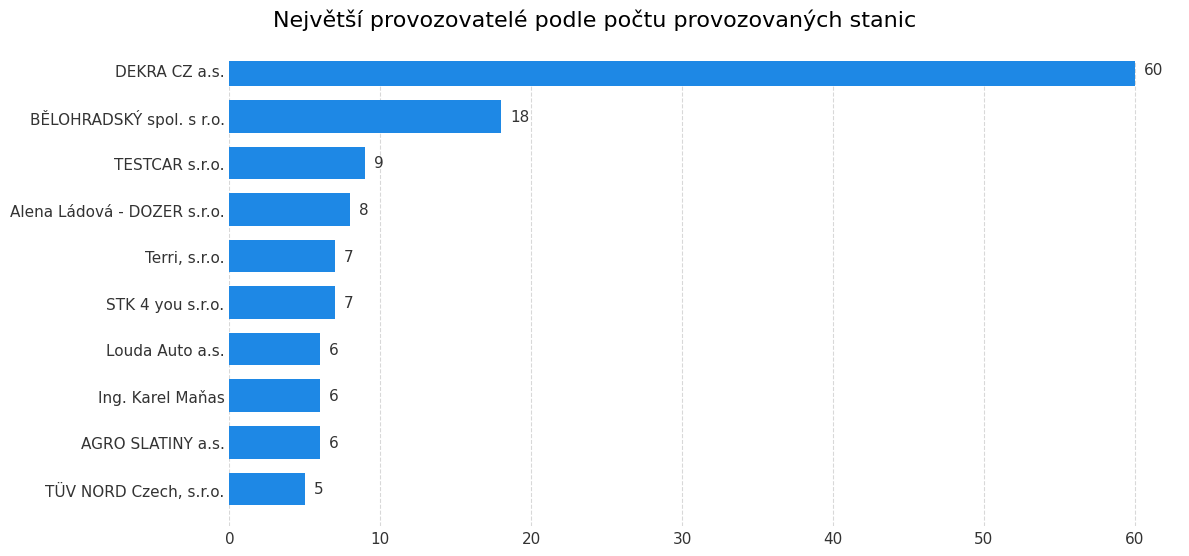

In [14]:
# Definice top n
n = 10

# Příprava dat z Polars DataFrame (df)
top_provozovatele = df.group_by('Provozovatel_Nazev').len().sort('len', 'Provozovatel_Nazev', descending=True).head(n).reverse()

labels = top_provozovatele['Provozovatel_Nazev'].to_list()
counts = top_provozovatele['len'].to_list()
title = f'Největší provozovatelé podle počtu provozovaných stanic'
path = 'kod/explorace/stanice_top_provozovatele.svg'

horizontal_bar(labels, counts, title, path)

In [15]:
print(f'Prumerny pocet stanic jednoho provozovatele {df.group_by('Provozovatel_Nazev').len().select(pl.col('len').mean()).item()}')
print(f'Podíl stanic provozvaných velkými hráči majících STK oprávnění: {df.filter(pl.col('Provozovatel_Nazev').is_in(list(top_provozovatele['Provozovatel_Nazev']))).select((pl.col('Stk_Pritomno') == 'True').mean()).item()*100:.2f} %')

Prumerny pocet stanic jednoho provozovatele 1.4412665985699693
Podíl stanic provozvaných velkými hráči majících STK oprávnění: 55.30 %


# Profile report

In [16]:
# profile = ProfileReport(df.to_pandas(), explorative=True)
# profile.to_file('kod/reporty/Stanice_STK_a_SME.html')